# The exact Gauss-Legendre scheme's error table (Block C, C2)

This notebook **computes nothing**. It loads what `run_scheme_grid.py`,
`make_tables.py` and `plot.py` wrote and displays it. Every number below is
read from `results/`; the argument that goes with them is in
[README.md](README.md).

The subject is the scheme with **no network in it**: the implicit collocation
equations solved to a residual of 1e-9 mm / mrad, so that what is measured is
the discretisation error of the scheme itself. That error is the ceiling for
any network trained on those equations.

In [1]:
import os
for _v in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS",
           "NUMEXPR_NUM_THREADS"):
    os.environ[_v] = "1"
os.environ["PYTHONNOUSERSITE"] = "1"
import json
import numpy as np
import pandas as pd
from IPython.display import Image, display
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 200)
RESULTS, FIGURES = "results", "figures"

STRATA = ["0.05-0.2 mm", "0.5-2 mm", "5-20 mm", "50-200 mm", "500-2000 mm",
          "full crossing"]
meta = json.load(open(os.path.join(RESULTS, "scheme_grid_meta.json")))
pd.Series({"dataset": os.path.basename(meta["dataset"]),
           "split": meta["split"], "cap per stratum": meta["cap_per_stratum"],
           "q values": str(meta["q_values"]),
           "field": meta["field"]["which"],
           "field md5": meta["field"]["md5"],
           "reference": meta["reference"]["integrator"],
           "reference step [mm]": meta["reference"]["step_mm"],
           "reference floor [um]": meta["reference"]["floor_um"],
           "residual tolerance": meta["solver"]["residual_tol"],
           "unknowns per state": meta["solver"]["unknowns_per_state"],
           "initial guess": meta["solver"]["initial_guess"],
           "grid wall [s]": meta["wall_s"]})

dataset                                            magnet_tracks_v3.npz
split                                                              test
cap per stratum                                                    2000
q values                           [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
field                                                                up
field md5                              9e49ddc4313b589f273540e7e0bb513b
reference                         fp64 RK6 (Butcher, 7 stages, order 6)
reference step [mm]                                                 0.1
reference floor [um]                                            0.00005
residual tolerance                                                  0.0
unknowns per state                               4 * q (q/p held fixed)
initial guess           straight line from the input state at the nodes
grid wall [s]                                                    2888.5
dtype: object

## C2.3 The scheme table

`results/scheme_table.csv`: one row per (q, stratum, direction). `both` is the
pooled row; `+1` and `-1` are the forward (dz > 0) and backward (dz < 0)
halves. The error statistics are over the converged solves of the cell.

In [2]:
S = pd.read_csv(os.path.join(RESULTS, "scheme_table.csv"))
L = pd.read_csv(os.path.join(RESULTS, "straight_line_table.csv"))
S["stratum"] = pd.Categorical(S["stratum"], STRATA, ordered=True)
L["stratum"] = pd.Categorical(L["stratum"], STRATA, ordered=True)
print(len(S), "scheme rows,", len(L), "straight-line rows")
S[S.direction == "both"].head(12)

180 scheme rows, 18 straight-line rows


,q,stratum,direction,n,n_converged,converged_frac,median_abs_dz_mm,endpoint_med_um,endpoint_p95_um,endpoint_mean_um,slope_err_med_mrad,median_n_eval,wall_s
0,2,0.05-0.2 mm,both,2000,2000,1.0,0.098223,1.421085e-11,2.273737e-10,4.184840e-11,3.469447e-15,13.0,11.497387
3,2,0.5-2 mm,both,2000,2000,1.0,0.996571,2.344791e-10,1.534772e-09,6.109879e-10,6.938894e-14,13.0,11.553967
6,2,5-20 mm,both,2000,2000,1.0,10.004636,3.183231e-09,7.969216e-06,3.576758e-06,9.992007e-13,25.0,18.241757
9,2,50-200 mm,both,2000,2000,1.0,101.915787,3.211036e-03,1.299060e-01,3.350380e-02,6.585663e-05,14.0,14.637124
12,2,500-2000 mm,both,2000,2000,1.0,997.895837,1.278549e+01,5.115665e+02,1.405119e+02,9.255245e-03,16.0,14.139390
15,2,full crossing,both,2000,2000,1.0,5174.685791,9.255982e+03,5.583913e+04,1.792261e+04,3.880521e+00,18.0,14.984193
18,4,0.05-0.2 mm,both,2000,2000,1.0,0.098223,1.421085e-11,2.273737e-10,4.184840e-11,3.469447e-15,21.0,17.150271
21,4,0.5-2 mm,both,2000,2000,1.0,0.996571,2.348677e-10,1.534772e-09,4.647209e-10,6.938894e-14,21.0,17.650217
24,4,5-20 mm,both,2000,2000,1.0,10.004636,3.069545e-09,1.704102e-06,7.216684e-07,9.436896e-13,42.0,28.586543
27,4,50-200 mm,both,2000,2000,1.0,101.915787,7.494392e-04,3.078818e-02,7.043972e-03,1.610998e-05,22.0,21.623956


### The grid the study is about

Endpoint error against the fine reference, **median micron**, both directions
pooled, and the straight line (magnet off) underneath it as the null step.

In [3]:
grid = (S[S.direction == "both"]
        .pivot(index="q", columns="stratum", values="endpoint_med_um"))
line = (L[L.direction == "both"].set_index("stratum")["endpoint_med_um"]
        .reindex(STRATA))
grid.loc["straight line"] = line
grid.style.format("{:.4g}")

stratum,0.05-0.2 mm,0.5-2 mm,5-20 mm,50-200 mm,500-2000 mm,full crossing
q,,,,,,
2,1.421e-11,2.345e-10,3.183e-09,0.003211,12.79,9256
4,1.421e-11,2.349e-10,3.07e-09,0.0007494,1.218,3617
6,1.421e-11,2.345e-10,3.07e-09,0.0003483,0.8252,232.6
8,1.421e-11,2.345e-10,3.048e-09,0.0002007,0.6958,32.63
10,1.421e-11,2.309e-10,3.038e-09,0.000137,0.5044,32.49
12,1.421e-11,2.345e-10,3.02e-09,9.708e-05,0.3964,41.5
14,1.421e-11,2.345e-10,3.038e-09,6.498e-05,0.3038,20.36
16,1.421e-11,2.345e-10,3.013e-09,5.335e-05,0.2189,36.13
18,1.421e-11,2.274e-10,3.002e-09,4.208e-05,0.1671,38.62


In [4]:
# p95 and mean, pooled
p95 = (S[S.direction == "both"]
       .pivot(index="q", columns="stratum", values="endpoint_p95_um"))
p95.loc["straight line"] = (L[L.direction == "both"]
                            .set_index("stratum")["endpoint_p95_um"]
                            .reindex(STRATA))
print("p95 endpoint error [um]")
display(p95.style.format("{:.4g}"))
mean = (S[S.direction == "both"]
        .pivot(index="q", columns="stratum", values="endpoint_mean_um"))
mean.loc["straight line"] = (L[L.direction == "both"]
                             .set_index("stratum")["endpoint_mean_um"]
                             .reindex(STRATA))
print("mean endpoint error [um]")
display(mean.style.format("{:.4g}"))

p95 endpoint error [um]


stratum,0.05-0.2 mm,0.5-2 mm,5-20 mm,50-200 mm,500-2000 mm,full crossing
q,,,,,,
2,2.274e-10,1.535e-09,7.969e-06,0.1299,511.6,5.584e+04
4,2.274e-10,1.535e-09,1.704e-06,0.03079,24.12,2.498e+04
6,2.274e-10,1.508e-09,6.462e-07,0.0146,16.27,2682
8,2.274e-10,1.508e-09,4.314e-07,0.009133,11.63,666.9
10,2.274e-10,1.508e-09,2.83e-07,0.005367,9.13,359.3
12,2.274e-10,1.506e-09,1.661e-07,0.004201,8.131,338.7
14,2.274e-10,1.506e-09,1.452e-07,0.003014,6.464,188
16,2.274e-10,1.506e-09,9.277e-08,0.002229,5.176,290.4
18,2.274e-10,1.479e-09,7.706e-08,0.001795,5.188,201.2


mean endpoint error [um]


stratum,0.05-0.2 mm,0.5-2 mm,5-20 mm,50-200 mm,500-2000 mm,full crossing
q,,,,,,
2,4.185e-11,6.11e-10,3.577e-06,0.0335,140.5,1.792e+04
4,4.185e-11,4.647e-10,7.217e-07,0.007044,18.86,7050
6,4.185e-11,4.453e-10,3.665e-07,0.003316,10.31,951.9
8,4.185e-11,4.369e-10,2.254e-07,0.001878,5.35,249.9
10,4.185e-11,4.39e-10,1.624e-07,0.001281,5.332,281.9
12,4.185e-11,4.411e-10,8.746e-08,0.0009605,3.451,190.6
14,4.185e-11,4.376e-10,8.467e-08,0.0007565,2.565,163.6
16,4.185e-11,4.351e-10,4.813e-08,0.0005093,2.146,155
18,4.185e-11,4.337e-10,5.064e-08,0.0004319,1.509,150


In [5]:
print("slope error [mrad], median, pooled")
sl = (S[S.direction == "both"]
      .pivot(index="q", columns="stratum", values="slope_err_med_mrad"))
sl.loc["straight line"] = (L[L.direction == "both"]
                           .set_index("stratum")["slope_err_med_mrad"]
                           .reindex(STRATA))
sl.style.format("{:.4g}")

slope error [mrad], median, pooled


stratum,0.05-0.2 mm,0.5-2 mm,5-20 mm,50-200 mm,500-2000 mm,full crossing
q,,,,,,
2,3.469e-15,6.939e-14,9.992e-13,6.586e-05,0.009255,3.881
4,3.469e-15,6.939e-14,9.437e-13,1.611e-05,0.002316,1.495
6,3.469e-15,6.939e-14,9.437e-13,6.977e-06,0.001447,0.0249
8,3.469e-15,6.939e-14,9.437e-13,4.231e-06,0.001295,0.01208
10,3.469e-15,6.939e-14,9.437e-13,2.774e-06,0.0009583,0.009833
12,3.469e-15,6.939e-14,9.437e-13,2.02e-06,0.0007273,0.01643
14,3.469e-15,6.939e-14,9.437e-13,1.528e-06,0.000574,0.007759
16,3.469e-15,6.939e-14,9.437e-13,1.12e-06,0.000426,0.01436
18,3.469e-15,6.939e-14,9.437e-13,9.095e-07,0.0003327,0.01543


### Forward against backward

The dataset is balanced 50/50 in direction by construction, so a difference
between the two halves would be a property of the scheme (or of the map's
grid), not of the sample.

In [6]:
d = (S[S.direction != "both"]
     .pivot_table(index=["q", "stratum"], columns="direction",
                  values="endpoint_med_um", observed=True))
d["ratio +1 / -1"] = d["+1"] / d["-1"]
d.tail(24).style.format("{:.4g}")

### The straight line, on its own

The end state obtained by carrying the input state along its own slopes: the
answer with the magnet switched off. Any scheme has to beat it, and on the
shortest steps the margin is enormous, which is the point of the strata.

In [7]:
L.set_index(["stratum", "direction"]).sort_index()

n  median_abs_dz_mm  endpoint_med_um  endpoint_p95_um  endpoint_mean_um  slope_err_med_mrad
stratum       direction                                                                                                
0.05-0.2 mm   +1         1017          0.097513         0.000127     9.510493e-04          0.000261            0.002888
              -1          983          0.099231         0.000132     1.065740e-03          0.000272            0.002760
              both       2000          0.098223         0.000131     1.024729e-03          0.000266            0.002850
0.5-2 mm      +1         1000          1.002988         0.014008     9.799489e-02          0.026965            0.029531
              -1         1000          0.988381         0.013845     1.102466e-01          0.028161            0.028040
              both       2000          0.996571         0.013897     1.021370e-01          0.027563            0.028670
5-20 mm       +1          994         10.361438         1.463598     1.022243e+01          2.882061            0.288875
              -1         1006          9.801871         1.391558     9.230884e+00          2.611029            0.296262
              both       2000         10.004636         1.415065     9.775438e+00          2.745732            0.291185
50-200 mm     +1          968        103.912801       143.455285     9.982620e+02        277.218894            2.941129
              -1         1032         99.837563       140.253414     1.056384e+03        279.733894            2.952671
              both       2000        101.915787       141.050707     1.045523e+03        278.516634            2.944591
500-2000 mm   +1          988        994.602127     16359.267616     1.010980e+05      29291.471088           35.188438
              -1         1012        999.491999     15658.961022     1.082058e+05      28702.514768           32.762243
              both       2000        997.895837     15985.931710     1.061253e+05      28993.459190           33.625780
full crossing +1         1001       5174.714111    461912.954382     1.279197e+06     540432.954796          175.813309
              -1          999       5174.636475    449115.820734     1.317812e+06     541152.096541          176.447151
              both       2000       5174.685791    456075.174617     1.297360e+06     540792.166097          176.207268

### Convergence and cost

`converged_frac` is the fraction of the cell's states whose residual came out
below 1e-9 in mm and mrad. `median_n_eval` is the median number of residual
evaluations one solve took, and one residual evaluation is one call of the
LHCb right-hand side at all q nodes at once.

In [8]:
conv = (S[S.direction == "both"]
        .pivot(index="q", columns="stratum", values="converged_frac"))
display(conv.style.format("{:.4f}"))
nev = (S[S.direction == "both"]
       .pivot(index="q", columns="stratum", values="median_n_eval"))
nev["4q + 5"] = [4 * q + 5 for q in nev.index]
display(nev.style.format("{:.0f}"))

stratum,0.05-0.2 mm,0.5-2 mm,5-20 mm,50-200 mm,500-2000 mm,full crossing
q,,,,,,
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
10,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
12,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
14,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
16,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
18,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


stratum,0.05-0.2 mm,0.5-2 mm,5-20 mm,50-200 mm,500-2000 mm,full crossing,4q + 5
q,,,,,,,
2,13,13,25,14,16,18,13
4,21,21,42,22,24,26,21
6,29,29,58,30,32,34,29
8,37,37,74,38,40,42,37
10,45,45,90,46,48,50,45
12,53,53,106,54,56,58,53
14,61,61,122,62,64,66,61
16,69,69,138,70,72,74,69
18,77,77,154,78,80,82,77


In [9]:
wall = (S[S.direction == "both"]
        .pivot(index="q", columns="stratum", values="wall_s"))
wall["row total [s]"] = wall.sum(axis=1)
display(wall.style.format("{:.0f}"))
print("whole grid: %.0f s = %.2f h on one core"
      % (wall["row total [s]"].sum(), wall["row total [s]"].sum() / 3600))

stratum,0.05-0.2 mm,0.5-2 mm,5-20 mm,50-200 mm,500-2000 mm,full crossing,row total [s]
q,,,,,,,
2,11,12,18,15,14,15,85
4,17,18,29,22,20,21,126
6,23,25,39,29,26,27,168
8,29,30,49,37,33,36,214
10,36,37,60,45,39,40,257
12,45,43,73,62,46,48,317
14,50,50,91,60,53,53,357
16,55,58,101,68,64,60,406
18,65,63,112,75,66,66,448


whole grid: 2857 s = 0.79 h on one core


## The figures

`figures/scheme_error_vs_dz_and_q.png` - error against step length (one curve
per q, the straight line dashed, the reference floor marked) and error against
q (one curve per stratum).

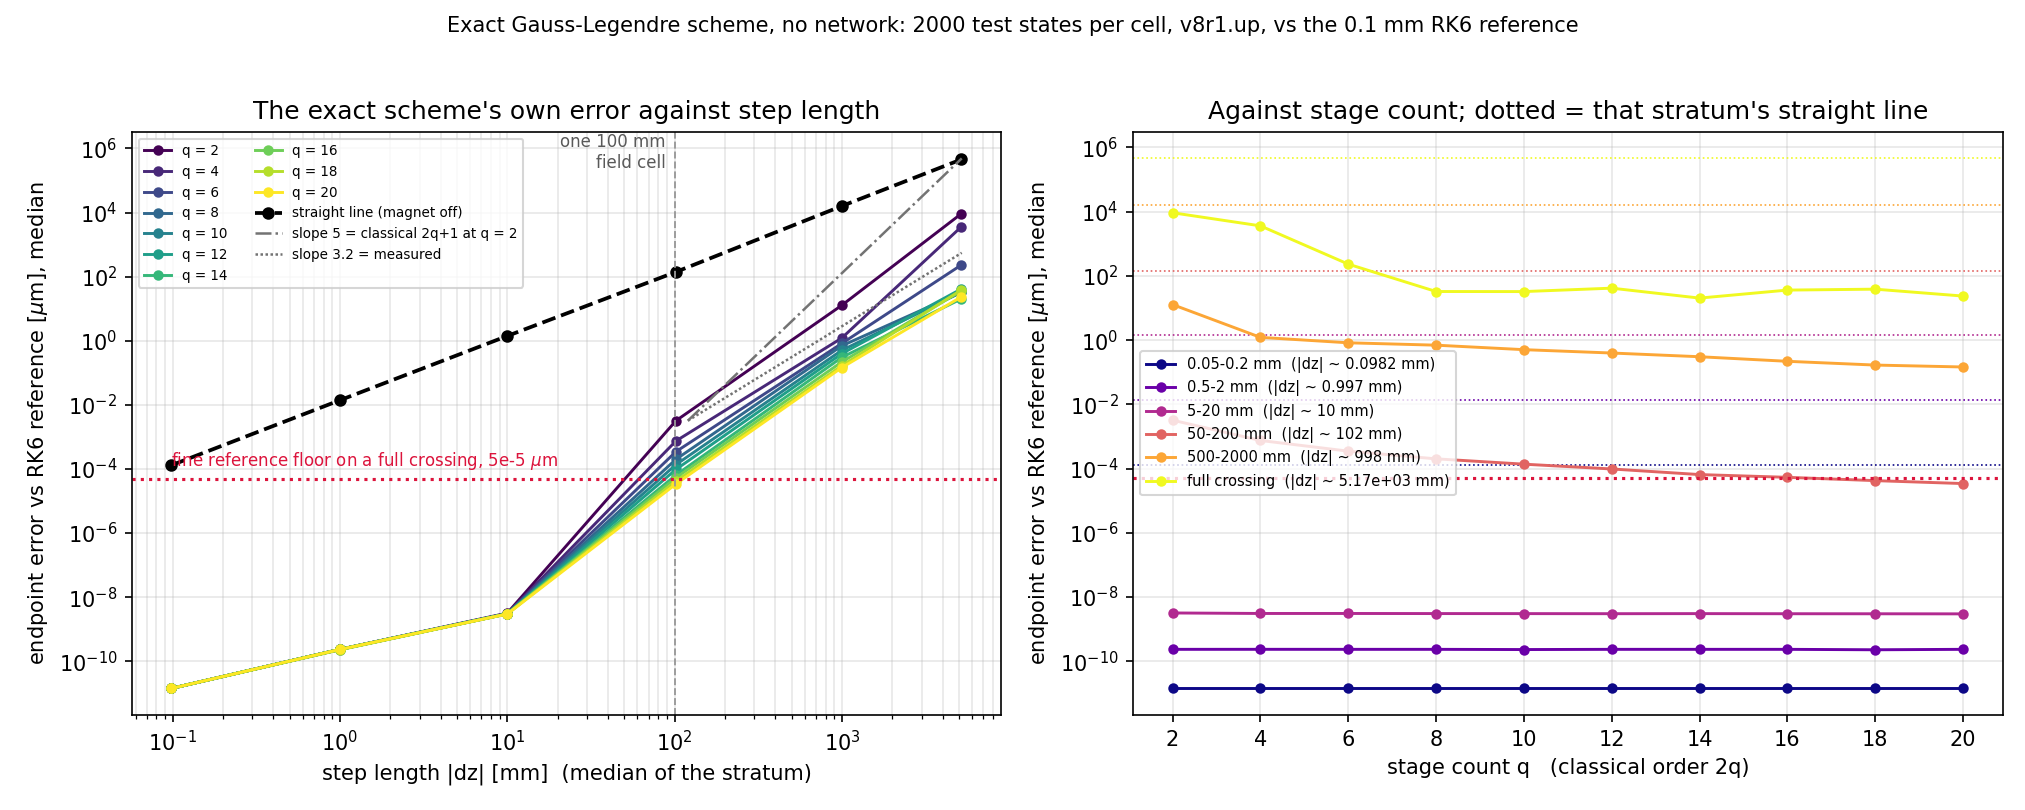

In [10]:
display(Image(os.path.join(FIGURES, "scheme_error_vs_dz_and_q.png")))

`figures/scheme_convergence_fraction.png` - the converged fraction as a
q x stratum map and as curves, and what one solve costs.

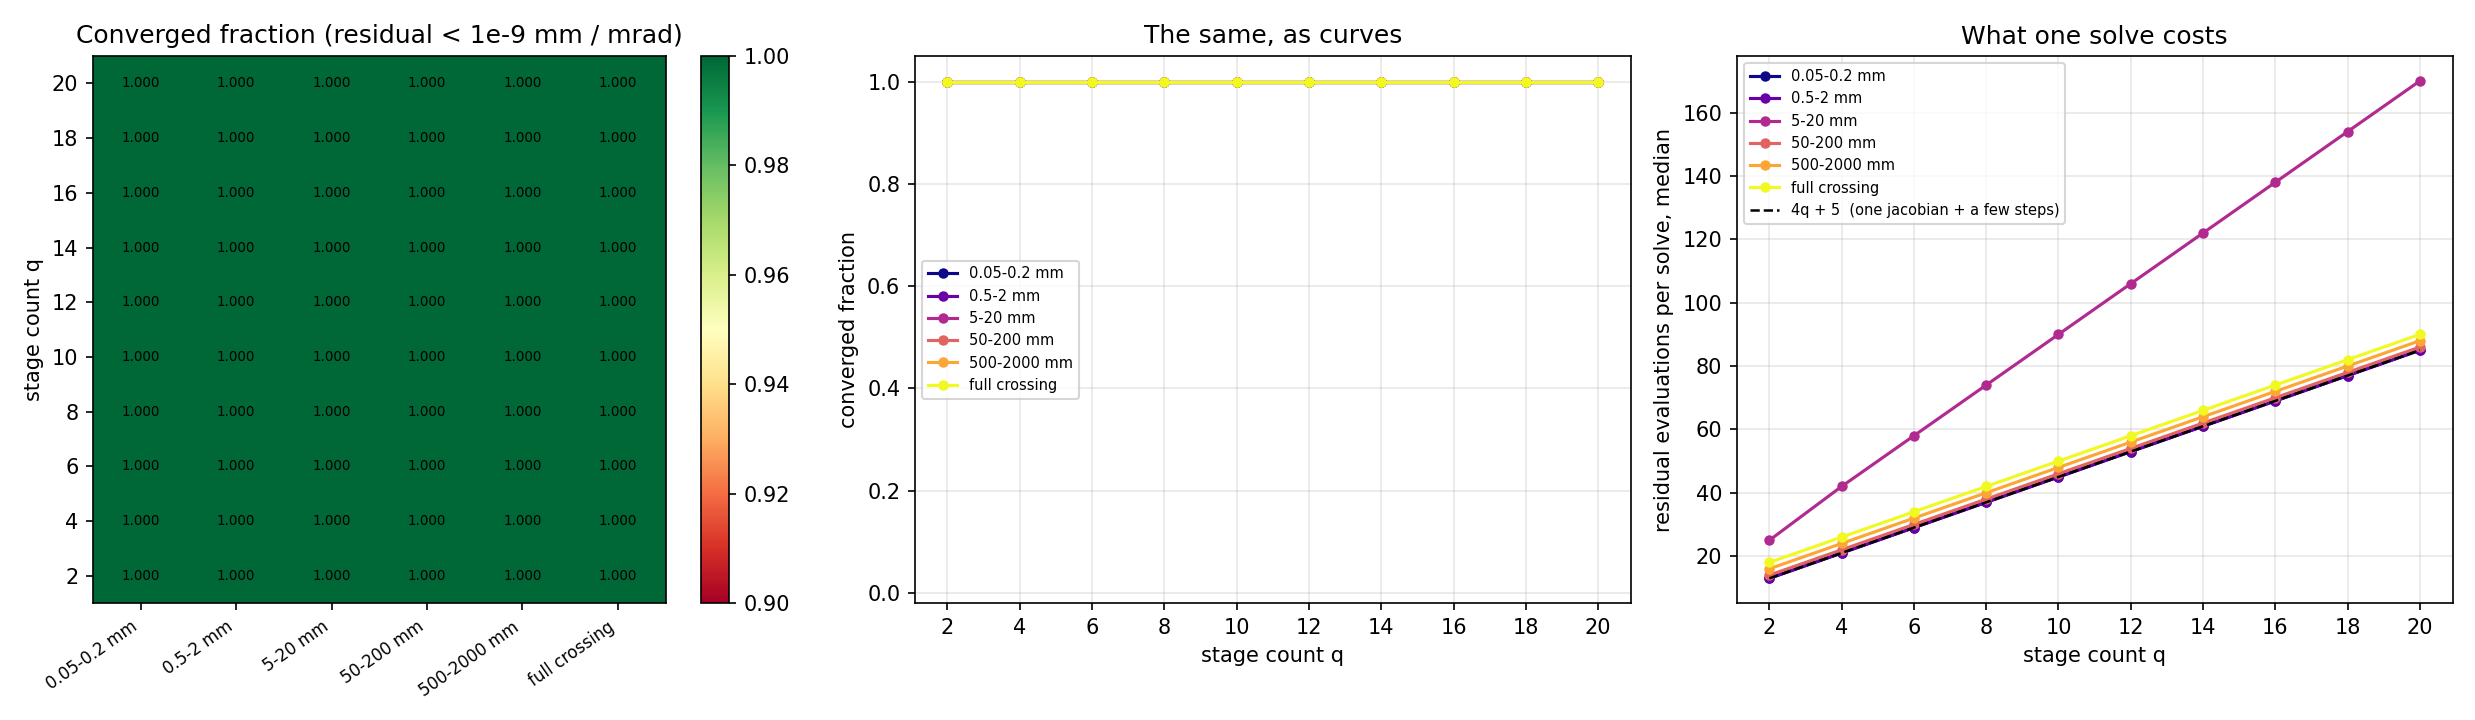

In [11]:
display(Image(os.path.join(FIGURES, "scheme_convergence_fraction.png")))

## C2.4 The rows to carry forward

The ceiling row is the one a network on this dataset is measured against.

In [12]:
rd = json.load(open(os.path.join(RESULTS, "reading.json")))
pd.Series(rd["headline"]).astype(str)

reference_floor_um                                                            5e-05
field_cell_mm                                                                 100.0
states_per_cell                                                                2000
cells_in_the_grid                                                                60
solves                                                                       120000
converged_frac_min                                                              1.0
full_crossing_q8_med_um                                           32.62632016858902
full_crossing_q8_p95_um                                           666.9194525158695
full_crossing_best_q                                                             14
full_crossing_best_med_um                                        20.359926257235372
full_crossing_plateau_q_ge_8_um    [32.63, 32.49, 41.5, 20.36, 36.13, 38.62, 23.56]
full_crossing_plateau_range_um                                        [20.36

In [13]:
pd.DataFrame(rd["per_stratum"]).set_index("stratum")[
    ["median_abs_dz_mm", "field_cells_crossed", "med_q2_um", "med_q20_um",
     "gain_med", "p95_q2_um", "p95_q20_um", "gain_p95", "best_q",
     "straight_line_um", "verdict"]]

,median_abs_dz_mm,field_cells_crossed,med_q2_um,med_q20_um,gain_med,p95_q2_um,p95_q20_um,gain_p95,best_q,straight_line_um,verdict
stratum,,,,,,,,,,,
0.05-0.2 mm,0.098223,0.000982,1.421085e-11,1.421085e-11,1.000000,2.273737e-10,2.273737e-10,1.000000,2,0.000131,at the reference floor - the scheme's own erro...
0.5-2 mm,0.996571,0.009966,2.344791e-10,2.344791e-10,1.000000,1.534772e-09,1.479350e-09,1.037464,18,0.013897,at the reference floor - the scheme's own erro...
5-20 mm,10.004636,0.100046,3.183231e-09,2.984279e-09,1.066667,7.969216e-06,7.049721e-08,113.043000,20,1.415065,at the reference floor - the scheme's own erro...
50-200 mm,101.915787,1.019158,3.211036e-03,3.410950e-05,94.139050,1.299060e-01,1.356969e-03,95.732492,20,141.050707,resolved - the scheme's own error is being mea...
500-2000 mm,997.895837,9.978958,1.278549e+01,1.456816e-01,87.763256,5.115665e+02,4.421202e+00,115.707565,20,15985.931710,resolved - the scheme's own error is being mea...
full crossing,5174.685791,51.746858,9.255982e+03,2.355980e+01,392.871800,5.583913e+04,1.396189e+02,399.939482,14,456075.174617,resolved - the scheme's own error is being mea...


In [14]:
print("the step-length slope at fixed q, against the classical 2q + 1")
display(pd.DataFrame(rd["step_length_order"]).set_index("q"))
print("the rows to carry into the network tables (q = 8 and q = 20)")
pd.DataFrame(rd["ceiling_row"]).set_index(["stratum", "q"])

the step-length slope at fixed q, against the classical 2q + 1


,classical_local_order,n_points,measured_slope
q,,,
2,5,3,3.777732
4,9,3,3.876433
6,13,3,3.414383
8,17,3,3.087318
10,21,3,3.179054
12,25,3,3.322702
14,29,3,3.252174
16,33,3,3.432681
18,37,2,3.306957


the rows to carry into the network tables (q = 8 and q = 20)


n  converged_frac        med_um        p95_um  slope_med_mrad  median_n_eval  evals_per_cell      wall_s
stratum       q                                                                                                              
0.05-0.2 mm   8   2000             1.0  1.421085e-11  2.273737e-10    3.469447e-15           37.0         74000.0   29.354427
              20  2000             1.0  1.421085e-11  2.273737e-10    3.469447e-15           85.0        170000.0   67.887536
0.5-2 mm      8   2000             1.0  2.344791e-10  1.507772e-09    6.938894e-14           37.0         74000.0   30.133297
              20  2000             1.0  2.344791e-10  1.479350e-09    6.938894e-14           85.0        170000.0   69.646677
5-20 mm       8   2000             1.0  3.048228e-09  4.314373e-07    9.436896e-13           74.0        148000.0   49.277162
              20  2000             1.0  2.984279e-09  7.049721e-08    9.436896e-13          170.0        340000.0  114.463704
50-200 mm     8   2000             1.0  2.007031e-04  9.132940e-03    4.230909e-06           38.0         76000.0   37.001931
              20  2000             1.0  3.410950e-05  1.356969e-03    7.494418e-07           86.0        172000.0   82.449445
500-2000 mm   8   2000             1.0  6.958438e-01  1.163298e+01    1.294625e-03           40.0         80000.0   32.593851
              20  2000             1.0  1.456816e-01  4.421202e+00    2.790128e-04           88.0        176000.0   72.683952
full crossing 8   2000             1.0  3.262632e+01  6.669195e+02    1.208098e-02           42.0         84000.0   35.647362
              20  2000             1.0  2.355980e+01  1.396189e+02    9.563534e-03           90.0        180000.0   71.904794